### **Importación de datos**



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)
tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:
# Calcular la facturación total de cada tienda
facturacion_tienda1 = tienda['Precio'].sum()
facturacion_tienda2 = tienda2['Precio'].sum()
facturacion_tienda3 = tienda3['Precio'].sum()
facturacion_tienda4 = tienda4['Precio'].sum()

# Imprimir los resultados
print("Facturación total de cada tienda:")
print(f"Tienda 1: ${facturacion_tienda1:,.2f}")
print(f"Tienda 2: ${facturacion_tienda2:,.2f}")
print(f"Tienda 3: ${facturacion_tienda3:,.2f}")
print(f"Tienda 4: ${facturacion_tienda4:,.2f}")

# Crear un diccionario para facilitar el análisis
facturacion_por_tienda = {
    "Tienda 1": facturacion_tienda1,
    "Tienda 2": facturacion_tienda2,
    "Tienda 3": facturacion_tienda3,
    "Tienda 4": facturacion_tienda4
}

# Encontrar la tienda con la mayor facturación
tienda_mayor_facturacion = max(facturacion_por_tienda, key=facturacion_por_tienda.get)
mayor_facturacion = facturacion_por_tienda[tienda_mayor_facturacion]

print(f"\nLa tienda con la mayor facturación es {tienda_mayor_facturacion} con un total de ${mayor_facturacion:,.2f}")

Facturación total de cada tienda:
Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00

La tienda con la mayor facturación es Tienda 1 con un total de $1,150,880,400.00


# 2. Ventas por categoría

In [4]:
def cantidad_productos_por_categoria(dataframes):
    """
    Calcula la cantidad de productos vendidos por categoría en cada tienda.

    Args:
        dataframes (dict): Un diccionario donde las claves son los nombres de las tiendas
                          y los valores son los DataFrames de cada tienda.

    Returns:
        dict: Un diccionario donde las claves son los nombres de las tiendas y los valores
              son DataFrames que muestran el conteo de productos por categoría.
    """

    resultados = {}

    for tienda, df in dataframes.items():
        # Agrupa por 'Categoría del Producto' y cuenta las ocurrencias
        conteo_por_categoria = df['Categoría del Producto'].value_counts().reset_index()
        conteo_por_categoria.columns = ['Categoría del Producto', 'Cantidad de Productos']
        resultados[tienda] = conteo_por_categoria

    return resultados

# Crea un diccionario con tus DataFrames
dataframes_tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

# Calcula la cantidad de productos por categoría para cada tienda
conteo_categorias_por_tienda = cantidad_productos_por_categoria(dataframes_tiendas)

# Muestra los resultados
for tienda, resultado in conteo_categorias_por_tienda.items():
    print(f"Tienda: {tienda}\n{resultado}\n")

Tienda: Tienda 1
    Categoría del Producto  Cantidad de Productos
0                  Muebles                    465
1             Electrónicos                    448
2                 Juguetes                    324
3        Electrodomésticos                    312
4     Deportes y diversión                    284
5   Instrumentos musicales                    182
6                   Libros                    173
7  Artículos para el hogar                    171

Tienda: Tienda 2
    Categoría del Producto  Cantidad de Productos
0                  Muebles                    442
1             Electrónicos                    422
2                 Juguetes                    313
3        Electrodomésticos                    305
4     Deportes y diversión                    275
5   Instrumentos musicales                    224
6                   Libros                    197
7  Artículos para el hogar                    181

Tienda: Tienda 3
    Categoría del Producto  Cantidad de Product

# 3. Calificación promedio de la tienda


In [5]:
def calcular_calificaciones_promedio(dataframes):
    """
    Calcula las calificaciones promedio de los clientes para cada tienda.

    Args:
        dataframes (dict): Un diccionario donde las claves son los nombres de las tiendas
                          y los valores son los DataFrames de cada tienda.

    Returns:
        dict: Un diccionario donde las claves son los nombres de las tiendas y los valores
              son las calificaciones promedio de los clientes.
    """

    calificaciones_promedio = {}

    for tienda, df in dataframes.items():
        # Calcula el promedio de la columna 'Calificación'
        promedio = df['Calificación'].mean()
        calificaciones_promedio[tienda] = promedio

    return calificaciones_promedio

# Supongamos que tienes tus DataFrames en un diccionario llamado 'dataframes_tiendas'
# dataframes_tiendas = {'Tienda 1': df_tienda1, 'Tienda 2': df_tienda2, 'Tienda 3': df_tienda3, 'Tienda 4': df_tienda4}

# Calcula las calificaciones promedio para cada tienda
promedios_tiendas = calcular_calificaciones_promedio(dataframes_tiendas)

# Muestra los resultados
for tienda, promedio in promedios_tiendas.items():
    print(f"Tienda: {tienda}, Calificación Promedio: {promedio:.2f}")

Tienda: Tienda 1, Calificación Promedio: 3.98
Tienda: Tienda 2, Calificación Promedio: 4.04
Tienda: Tienda 3, Calificación Promedio: 4.05
Tienda: Tienda 4, Calificación Promedio: 4.00


# 4. Productos más y menos vendidos

In [6]:
import pandas as pd

def productos_mas_menos_vendidos(dataframes):
    """
    Identifica los productos más y menos vendidos en cada tienda.

    Args:
        dataframes (dict): Un diccionario donde las claves son los nombres de las tiendas
                          y los valores son los DataFrames de cada tienda.

    Returns:
        dict: Un diccionario donde las claves son los nombres de las tiendas y los valores
              son diccionarios con los productos más y menos vendidos.
    """

    resultados = {}

    for tienda, df in dataframes.items():
        # Cuenta la cantidad de ventas por producto
        conteo_ventas = df['Producto'].value_counts().reset_index()
        conteo_ventas.columns = ['Producto', 'Cantidad de Ventas']

        # Encuentra el producto más vendido
        mas_vendido = conteo_ventas.iloc[0]

        # Encuentra el producto menos vendido
        menos_vendido = conteo_ventas.iloc[-1]

        resultados[tienda] = {
            'Más Vendido': mas_vendido.to_dict(),
            'Menos Vendido': menos_vendido.to_dict()
        }

    return resultados

# Calcula los productos más y menos vendidos para cada tienda
productos_vendidos_por_tienda = productos_mas_menos_vendidos(dataframes_tiendas)

# Muestra los resultados
for tienda, resultado in productos_vendidos_por_tienda.items():
    print(f"Tienda: {tienda}")
    print(f"  Más Vendido: {resultado['Más Vendido']['Producto']} (Cantidad: {resultado['Más Vendido']['Cantidad de Ventas']})")
    print(f"  Menos Vendido: {resultado['Menos Vendido']['Producto']} (Cantidad: {resultado['Menos Vendido']['Cantidad de Ventas']})")
    print("-" * 30)

Tienda: Tienda 1
  Más Vendido: Microondas (Cantidad: 60)
  Menos Vendido: Celular ABXY (Cantidad: 33)
------------------------------
Tienda: Tienda 2
  Más Vendido: Iniciando en programación (Cantidad: 65)
  Menos Vendido: Juego de mesa (Cantidad: 32)
------------------------------
Tienda: Tienda 3
  Más Vendido: Kit de bancas (Cantidad: 57)
  Menos Vendido: Bloques de construcción (Cantidad: 35)
------------------------------
Tienda: Tienda 4
  Más Vendido: Cama box (Cantidad: 62)
  Menos Vendido: Guitarra eléctrica (Cantidad: 33)
------------------------------


In [9]:
# Identificar los productos más y menos vendidos en la Tienda 1
conteo_productos_tienda1 = dataframes_tiendas['Tienda 1']['Producto'].value_counts()
producto_mas_vendido_tienda1 = conteo_productos_tienda1.index[0]
producto_menos_vendido_tienda1 = conteo_productos_tienda1.index[-1]
cantidad_mas_vendido_tienda1 = conteo_productos_tienda1.iloc[0]
cantidad_menos_vendido_tienda1 = conteo_productos_tienda1.iloc[-1]

print(f"Tienda 1: El producto más vendido es '{producto_mas_vendido_tienda1}' ({cantidad_mas_vendido_tienda1} unidades).")
print(f"Tienda 1: El producto menos vendido es '{producto_menos_vendido_tienda1}' ({cantidad_menos_vendido_tienda1} unidades).\n")

# ... (similar changes for Tienda 2, Tienda 3, and Tienda 4)

# For example, for Tienda 2:
conteo_productos_tienda2 = dataframes_tiendas['Tienda 2']['Producto'].value_counts()
# ...

Tienda 1: El producto más vendido es 'Microondas' (60 unidades).
Tienda 1: El producto menos vendido es 'Celular ABXY' (33 unidades).



In [14]:
# Identificar los productos más y menos vendidos en la Tienda 2
conteo_productos_tienda2 = dataframes_tiendas['Tienda 2']['Producto'].value_counts()
producto_mas_vendido_tienda2 = conteo_productos_tienda2.index[0]
producto_menos_vendido_tienda2 = conteo_productos_tienda2.index[-1]
cantidad_mas_vendido_tienda2 = conteo_productos_tienda2.iloc[0]
cantidad_menos_vendido_tienda2 = conteo_productos_tienda2.iloc[-1]

print(f"Tienda 2: El producto más vendido es '{producto_mas_vendido_tienda2}' ({cantidad_mas_vendido_tienda1} unidades).")
print(f"Tienda 2: El producto menos vendido es '{producto_menos_vendido_tienda2}' ({cantidad_menos_vendido_tienda2} unidades).\n")

# ... (similar changes for Tienda 2, Tienda 3, and Tienda 4)

# For example, for Tienda 2:
conteo_productos_tienda2 = dataframes_tiendas['Tienda 2']['Producto'].value_counts()
# ...

Tienda 2: El producto más vendido es 'Iniciando en programación' (60 unidades).
Tienda 2: El producto menos vendido es 'Juego de mesa' (32 unidades).



# 5. Envío promedio por tienda

In [18]:
def calcular_costo_promedio_envio(dataframes):
    """
    Calcula el costo de envío promedio para cada tienda.

    Args:
        dataframes (dict): Un diccionario donde las claves son los nombres de las tiendas
                          y los valores son los DataFrames de cada tienda.
    Returns:
        dict: Un diccionario donde las claves son los nombres de las tiendas y los valores
              son los costos de envío promedio.
    """
    costos_promedio = {}

    for tienda, df in dataframes.items():
        # Calcula el promedio de la columna 'Costo de envío'
        promedio = df['Costo de envío'].mean()
        costos_promedio[tienda] = promedio

    return costos_promedio

# Calcula los costos de envío promedio para cada tienda
promedios_envio_tiendas = calcular_costo_promedio_envio(dataframes_tiendas)

# Muestra los resultados
for tienda, promedio in promedios_envio_tiendas.items():
    print(f"Tienda: {tienda}, Costo de Envío Promedio: {promedio:.2f}")

Tienda: Tienda 1, Costo de Envío Promedio: 26018.61
Tienda: Tienda 2, Costo de Envío Promedio: 25216.24
Tienda: Tienda 3, Costo de Envío Promedio: 24805.68
Tienda: Tienda 4, Costo de Envío Promedio: 23459.46


**Gráfico facturacion Total por tienda**

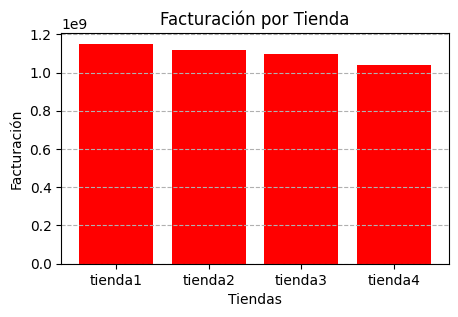

In [5]:
import matplotlib.pyplot as grafico

tiendas = ['tienda1', 'tienda2', 'tienda3','tienda4']
facturacion = [facturacion_tienda1, facturacion_tienda2, facturacion_tienda3, facturacion_tienda4]

grafico.figure(figsize=(5, 3))
grafico.bar(tiendas, facturacion, color='red')
grafico.xlabel('Tiendas')
grafico.ylabel('Facturación')
grafico.title('Facturación por Tienda')

grafico.grid(axis='y', linestyle='--')

grafico.show()

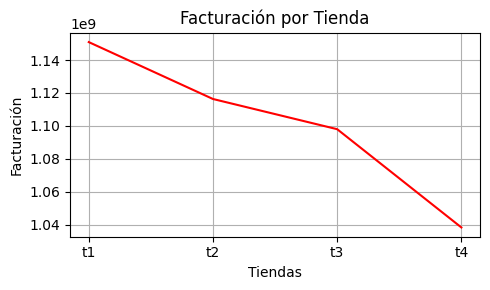

In [7]:
import matplotlib.pyplot as gra
tiendas = ['t1', 't2', 't3','t4']
facturacion = [facturacion_tienda1, facturacion_tienda2, facturacion_tienda3, facturacion_tienda4]

gra.figure(figsize=(5, 3))
gra.plot(tiendas, facturacion, color='red')
gra.xlabel('Tiendas')
gra.ylabel('Facturación')
gra.title('Facturación por Tienda')
gra.grid(True)
gra.tight_layout()
gra.show()

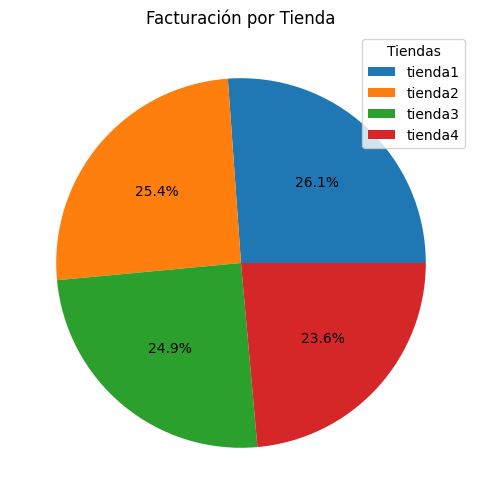

In [8]:
import matplotlib.pyplot as torta

# Datos de ejemplo (sustituye con tus datos reales)
tiendas = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
facturacion = [facturacion_tienda1, facturacion_tienda2, facturacion_tienda3, facturacion_tienda4]

# Crear DataFrame
df = pd.DataFrame({'Tiendas': tiendas, 'Facturacion': facturacion})

# Crear gráfico de torta
torta.figure(figsize=(6, 6))  # Tamaño del gráfico
torta.pie(df['Facturacion'], autopct='%1.1f%%', labels=None)  # Sin etiquetas en la torta

# Agregar leyenda en la esquina superior derecha
torta.legend(labels=df['Tiendas'], loc='upper right', title='Tiendas')

# Título del gráfico
torta.title('Facturación por Tienda')

# Mostrar gráfico
torta.show()

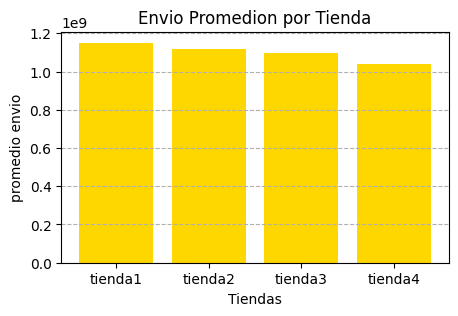

In [17]:
import matplotlib.pyplot as promedio

tiendas = ['tienda1', 'tienda2', 'tienda3','tienda4']
promedios_envio_tiendas[tienda] = promedio

promedio.figure(figsize=(5, 3))
promedio.bar(tiendas, facturacion, color='gold')
promedio.xlabel('Tiendas')
promedio.ylabel('promedio envio')
promedio.title('Envio Promedion por Tienda')

grafico.grid(axis='y', linestyle='--')

grafico.show()


#**Informe Final: Análisis de Rendimiento de las Tiendas**

 Ahora, con estos resultados en la mano, podemos ayudar al Don Juan a tomar una decisión informada sobre qué tienda a vender.

Vamos a analizar cada uno de los puntos para evaluar el rendimiento de cada tienda:

# **1. Facturación Total:**

* **Tienda 1:**  $1,150,880,400 ( mayor facturación)

* **Tienda 2:**  $1,116,343,500

* **Tienda 3:**  $1,098,019,600

* **Tienda 4:**  $1,038,375,700 (menor facturación)

En términos de ingresos brutos, la Tienda 4 es la que genera menos facturación.

#**2. Ventas por Categoría:**

En general, la categoría **"Muebles"** y **"Electrónicos"** son consistentemente las más vendidas en todas las tiendas en términos de cantidad de productos. No parece haber una diferencia drástica en las preferencias de categorías entre las tiendas que sugiera un rendimiento significativamente menor en alguna de ellas en este aspecto.

#**3. Calificación Promedio de los Clientes:**

* **Tienda 1:** 3.98 (menor calificación)
* **Tienda 2:** 4.04
* **Tienda 3:** 4.05 ( mayor calificación promedio)
* **Tienda 4:** 4.00

Las calificaciones promedio son bastante similares en todas las tiendas, con la Tienda 3 ligeramente por encima y la Tienda 1 ligeramente por debajo. Esto sugiere que la satisfacción del cliente es comparable entre las tiendas.

#**4. Productos Más y Menos Vendidos:**

Aquí vemos productos específicos que tienen un rendimiento alto y bajo en cada tienda. No hay un patrón claro de un producto consistentemente de bajo rendimiento en una tienda en particular que la señale como la de menor
desempeño general.


#**5. Costo Promedio de Envío:**

* **Tienda 1:** $26,018.61 (Mayor costo promedio de envío)

* **Tienda 2:** $25,216.24

* **Tienda 3:** $24,805.68

* **Tienda 4:** $23,459.46 (Menor costo promedio de envío)

La Tienda 4 tiene el costo promedio de envío más bajo, lo que podría ser una ventaja en términos de competitividad o margen de ganancia, dependiendo de cómo se gestione este costo. La Tienda 1 tiene el costo promedio de envío más alto.





#**Analisis " F.O.D.A.  : "**

El análisis de los cinco aspectos revela diferencias en el rendimiento de las cuatro tiendas:

- **Tienda 1**:  
  - **Fortalezas**: Líder en facturación ($1,150,880,400), con un alto volumen en ventas en las categoría más vendida Muebles.Y la segunda categoria mas vendida Electrónicos

  - **Debilidades**: Tiene la calificación promedio más baja (3.98) y el costo de envío más alto ($26,018.61), lo que podría afectar la satisfacción del cliente y la rentabilidad.  

- **Tienda 2**:  

  - **Fortalezas**: Buenos ingresos ($1,116,343,500) y el producto más vendido con mayor volumen (Iniciando en programación, 65 unidades). Calificación promedio sólida (4.04).  

  - **Debilidades**: Menor volumen en ventas de la categoría más vendida Muebles y costos de envío relativamente altos ($25,216).  

- **Tienda 3**:  

  - **Fortalezas**: Mejor calificación promedio (4.05) y líder en ventas de la categoría mas vendida Muebles (499 unidades). Costo de envío competitivo ($24,805).  

  - **Debilidades**: Ingresos más bajos que las Tiendas 1 y 2 ($1,098,019,600) y menor volumen en su producto más vendido (Kit de bancas, 57 unidades).  

- **Tienda 4**:  

  - **Fortalezas**: Costo de envío más bajo ($23,459) y volumen sólido en Muebles (480 unidades).  

  - **Debilidades**: Menor facturación ($1,038,375,700), calificación promedio moderada (4.00), y menor volumen en productos menos vendidos (Guitarra eléctrica, 33 unidades).  


**Comparación**:

 La **Tienda** 1 destaca por sus ingresos, pero sus altos costos de envío y baja calificación son preocupantes. La Tienda 2 tiene un desempeño equilibrado, con ingresos y calificaciones sólidas. La Tienda 3 sobresale en satisfacción del cliente y ventas de Muebles, pero sus ingresos son bajos. La **Tienda 4** tiene la facturación más baja y no lidera en ningún aspecto clave, aunque sus costos de envío son los más eficientes. Los ingresos son un factor crítico para la sostenibilidad del negocio, lo que pone a la Tienda 4 en desventaja.

# **Recomendación para Don Señor Juan:**

Basándonos en este análisis, la Tienda 4 parece ser la candidata más lógica para vender si el objetivo es deshacerse de la tienda con el menor desempeño en términos de facturación total. Aunque las calificaciones de los clientes son buenas y el costo de envío promedio es el más bajo, su facturación total es significativamente menor que la de las otras tres tiendas.